In [ ]:
!pip install torch torchvision timm pillow opencv-python numpy scikit-learn matplotlib seaborn tqdm pandas torchsummary


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import timm


In [ ]:
!C:\Users\User\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip

In [ ]:
!C:\Users\User\AppData\Local\Programs\Python\Python310\python.exe -m pip install torch torchvision timm pillow opencv-python numpy scikit-learn matplotlib seaborn tqdm pandas torchsummary

In [26]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import timm
import pandas as pd 

In [30]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")


CUDA available: False
GPU name: None


In [31]:
IMAGE_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_CLASSES = 31

DATASET_DIR = "FishImgDataset"  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


Device: cpu


In [32]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [33]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_DIR, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_DIR, "val"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_DIR, "test"),
    transform=val_test_transforms
)

print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))


Classes: ['Bangus', 'Big Head Carp', 'Black Spotted Barb', 'Catfish', 'Climbing Perch', 'Fourfinger Threadfin', 'Freshwater Eel', 'Glass Perchlet', 'Goby', 'Gold Fish', 'Gourami', 'Grass Carp', 'Green Spotted Puffer', 'Indian Carp', 'Indo-Pacific Tarpon', 'Jaguar Gapote', 'Janitor Fish', 'Knifefish', 'Long-Snouted Pipefish', 'Mosquito Fish', 'Mudfish', 'Mullet', 'Pangasius', 'Perch', 'Scat Fish', 'Silver Barb', 'Silver Carp', 'Silver Perch', 'Snakehead', 'Tenpounder', 'Tilapia']
Number of classes: 31


In [34]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 8793
Val samples: 2751
Test samples: 1760


In [35]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(DEVICE)
print(model)


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)


In [37]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


In [38]:
def validate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc


In [41]:
best_val_acc = 0.0

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader)
    val_acc = validate(model, val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_swin_fish_model1.pth")
        print("✔ Best model saved")



Epoch [1/10]


Validating: 100%|██████████| 344/344 [03:11<00:00,  1.80it/s]


Train Loss: 0.7120
Validation Accuracy: 0.9437
✔ Best model saved

Epoch [2/10]


Validating: 100%|██████████| 344/344 [02:19<00:00,  2.47it/s]


Train Loss: 0.2690
Validation Accuracy: 0.9371

Epoch [3/10]


...

Train Loss: 0.1041
Validation Accuracy: 0.9775

Epoch [8/10]


Validating: 100%|██████████| 344/344 [03:22<00:00,  1.70it/s]


Train Loss: 0.1062
Validation Accuracy: 0.9687

Epoch [9/10]


Training:   5%|▌         | 58/1100 [01:08<20:24,  1.18s/it]


KeyboardInterrupt: 

In [42]:
model.load_state_dict(
    torch.load("best_swin_fish_model1.pth")
)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=test_dataset.classes
    )
)


Testing: 100%|██████████| 220/220 [03:30<00:00,  1.04it/s]


Test Accuracy: 0.9778

Classification Report:
                       precision    recall  f1-score   support

               Bangus       0.94      0.97      0.96        34
        Big Head Carp       0.96      1.00      0.98        43
   Black Spotted Barb       1.00      0.97      0.99        40
              Catfish       0.95      0.98      0.97        62
       Climbing Perch       1.00      0.93      0.97        30
 Fourfinger Threadfin       1.00      0.97      0.99        38
       Freshwater Eel       0.92      1.00      0.96        55
       Glass Perchlet       1.00      0.97      0.99        77
                 Goby       0.98      1.00      0.99       124
            Gold Fish       1.00      1.00      1.00        41
              Gourami       1.00      0.98      0.99        63
           Grass Carp       1.00      1.00      1.00       238
 Green Spotted Puffer       1.00      1.00      1.00        22
          Indian Carp       1.00      1.00      1.00        53
  Indo-

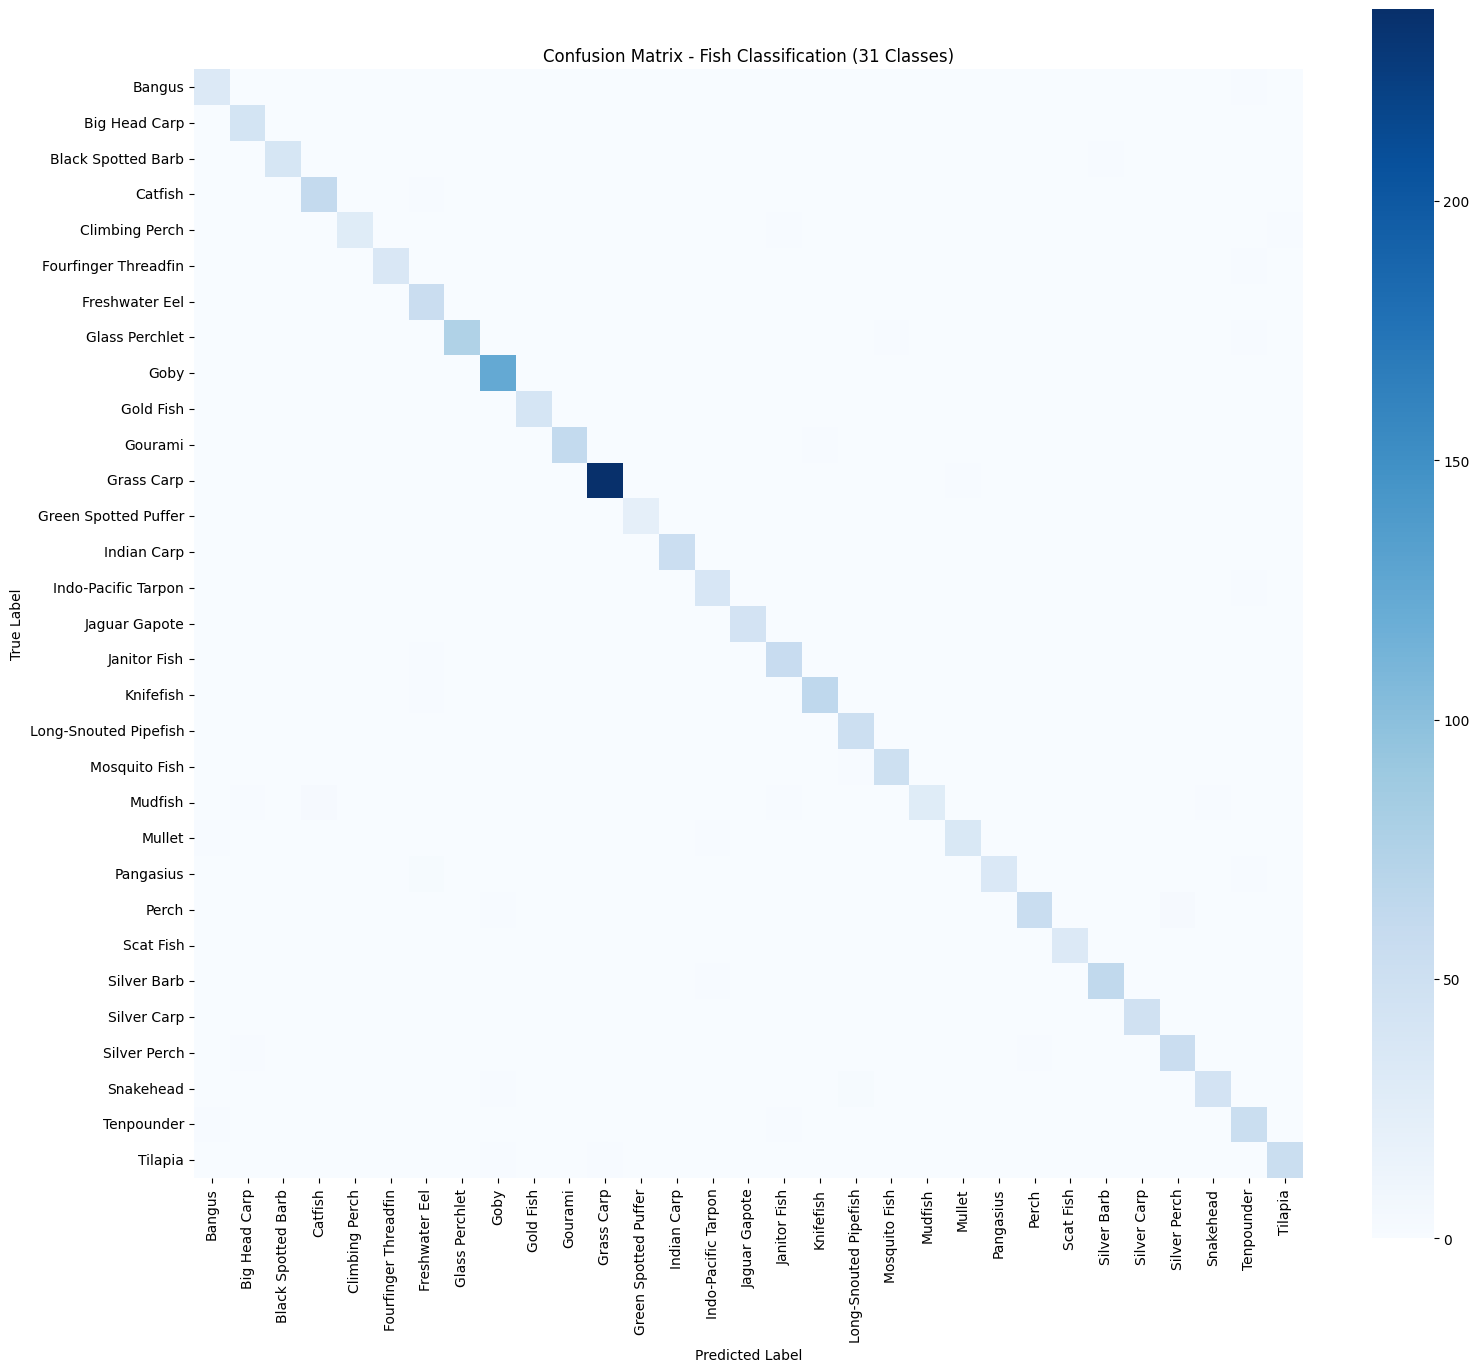

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)


plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes,
    square=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fish Classification (31 Classes)")
plt.tight_layout()
plt.show()



In [ ]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cpu


In [ ]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
model.load_state_dict(torch.load("best_swin_fish_model1.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [ ]:
def predict_single_image(image_path, model, classes):
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

    predicted_class = classes[pred_idx]
    confidence = probs[0, pred_idx].item()

    plt.figure(figsize=(4,4))
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence


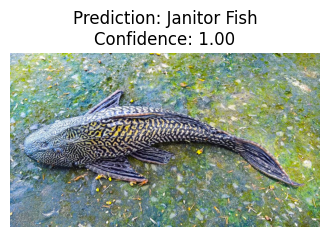

('Janitor Fish', 0.9999523162841797)

In [ ]:
image_path = r"C:\Users\User\Downloads\Janitor-Fish.jpg"  
predict_single_image(image_path, model, test_dataset.classes)
